<div style="border:solid green 2px; padding: 20px"> <h1 style="color:green; margin-bottom:20px">Reviewer's comment v1</h1>

Hello Kelvin!

I'm happy to review your project today 🙌

My name is Gerardo Flores and you an find me on Discord as **gerardo.flores.ds**

You can find my comments under the heading **«Review»**. I will categorize my comments in green, blue or red boxes like this:

<div class="alert alert-success">
    <b>Success:</b> if everything is done successfully
</div>
<div class="alert alert-warning">
    <b>Remarks:</b> if I can give some recommendations or ways to improve the project
</div>
<div class="alert alert-danger">
    <b>Needs fixing:</b> if the block requires some corrections. Work can't be accepted with the red comments
</div>

Please don't remove my comments. If you have any questions, don't hesitate to respond to my comments in a different section.
    
<div class="alert alert-info"> <b>Student comments:</b> For example like this</div>     


<div style="border:solid green 2px; padding: 20px">
<b>Reviewer's comment v1</b>
    
<b>General Feedback</b>  
 
    
You’ve submitted another project—great work! Your commitment to pushing through the challenges of this program is admirable.

After reviewing your submission, there are no critical issues, so your project has been accepted!. You can find my more detailed feedback within your project file in the **Reviewer's comment v1** section.
    
you did an amazing job! 💫 


Wishing you interesting projects in the upcoming sprints! ☘️
    
And of course, if you have any questions along the way, remember that you can always reach out to your tutor for any clarification.
</div>

# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

## Initialization

## The Film Junky Union

In this project, I aim to build a machine learning model that can automatically detect negative movie reviews. The task is based on a dataset of IMDB reviews provided by the Film Junky Union, a community for classic movie enthusiasts. The goal is to classify reviews as positive or negative using text data, reaching an F1 score of at least 0.85 for reliable performance. To achieve this, I will perform thorough data preprocessing, exploratory data analysis (EDA), and train multiple classification models to evaluate their effectiveness. The project ultimately seeks to support the development of a review moderation system that filters content based on sentiment.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1</b>
 
Great job adding additional information about the project goal. It would also be helpful to share the steps you plan to complete.

</div>

In [18]:
import math
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from tqdm.auto import tqdm
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import transformers

In [19]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [20]:
# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Load Data

In [21]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [22]:
df_reviews.info()
df_reviews.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


In [23]:
df_reviews.describe(include='all')

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
count,47331,47331,47331,47331,47331.000000,47331,47331,47331.000000,47331,47329.000000,4.732900e+04,47331,47331.000000,47331,47331.000000,47331,47331.000000
unique,6648,10,6555,6562,NaN,60,249,NaN,585,NaN,NaN,47240,NaN,2,NaN,2,NaN
top,tt0187078,movie,The Sentinel,The Sentinel,NaN,\N,90,NaN,Drama,NaN,NaN,Loved today's show!!! It was a variety and not...,NaN,neg,NaN,train,NaN
freq,30,36861,60,60,NaN,45052,2442,NaN,3392,NaN,NaN,5,NaN,23715,NaN,23796,NaN
mean,NaN,NaN,NaN,NaN,1989.631235,NaN,NaN,0.001732,NaN,5.998278,2.556292e+04,NaN,5.484608,NaN,0.498954,NaN,6279.697999
std,NaN,NaN,NaN,NaN,19.600364,NaN,NaN,0.041587,NaN,1.494289,8.367004e+04,NaN,3.473109,NaN,0.500004,NaN,3605.702545
min,NaN,NaN,NaN,NaN,1894.000000,NaN,NaN,0.000000,NaN,1.400000,9.000000e+00,NaN,1.000000,NaN,0.000000,NaN,0.000000
25%,NaN,NaN,NaN,NaN,1982.000000,NaN,NaN,0.000000,NaN,5.100000,8.270000e+02,NaN,2.000000,NaN,0.000000,NaN,3162.000000
50%,NaN,NaN,NaN,NaN,1998.000000,NaN,NaN,0.000000,NaN,6.300000,3.197000e+03,NaN,4.000000,NaN,0.000000,NaN,6299.000000
75%,NaN,NaN,NaN,NaN,2004.000000,NaN,NaN,0.000000,NaN,7.100000,1.397400e+04,NaN,9.000000,NaN,1.000000,NaN,9412.000000


In [1]:
df_reviews.isnull().sum()

NameError: name 'df_reviews' is not defined

The necessary Python libraries for data manipulation, visualization, and modeling were imported, including pandas, numpy, matplotlib, seaborn, sklearn, nltk, and transformers. The dataset imdb_reviews.tsv was loaded into a pandas DataFrame using the read_csv() function with a tab delimiter, and the votes column was explicitly cast to the Int64 data type. To understand the dataset structure, the info() and head() methods were used, revealing that the dataset contains 47,331 entries across 17 columns.
The describe method was used to generate summary statistics, such as the number of unique values, most frequent values, and basic numerical distributions across all columns. Finally, missing values in the dataset were identified using the isnull().sum() function, which showed that some columns, including average_rating, votes, genres, and review, contained a small number of null values. This step helped identify which fields may require preprocessing before modeling.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>
    
Well done! Cocnlusions looks great! Nice!

## EDA

Let's check the number of movies and reviews over years.

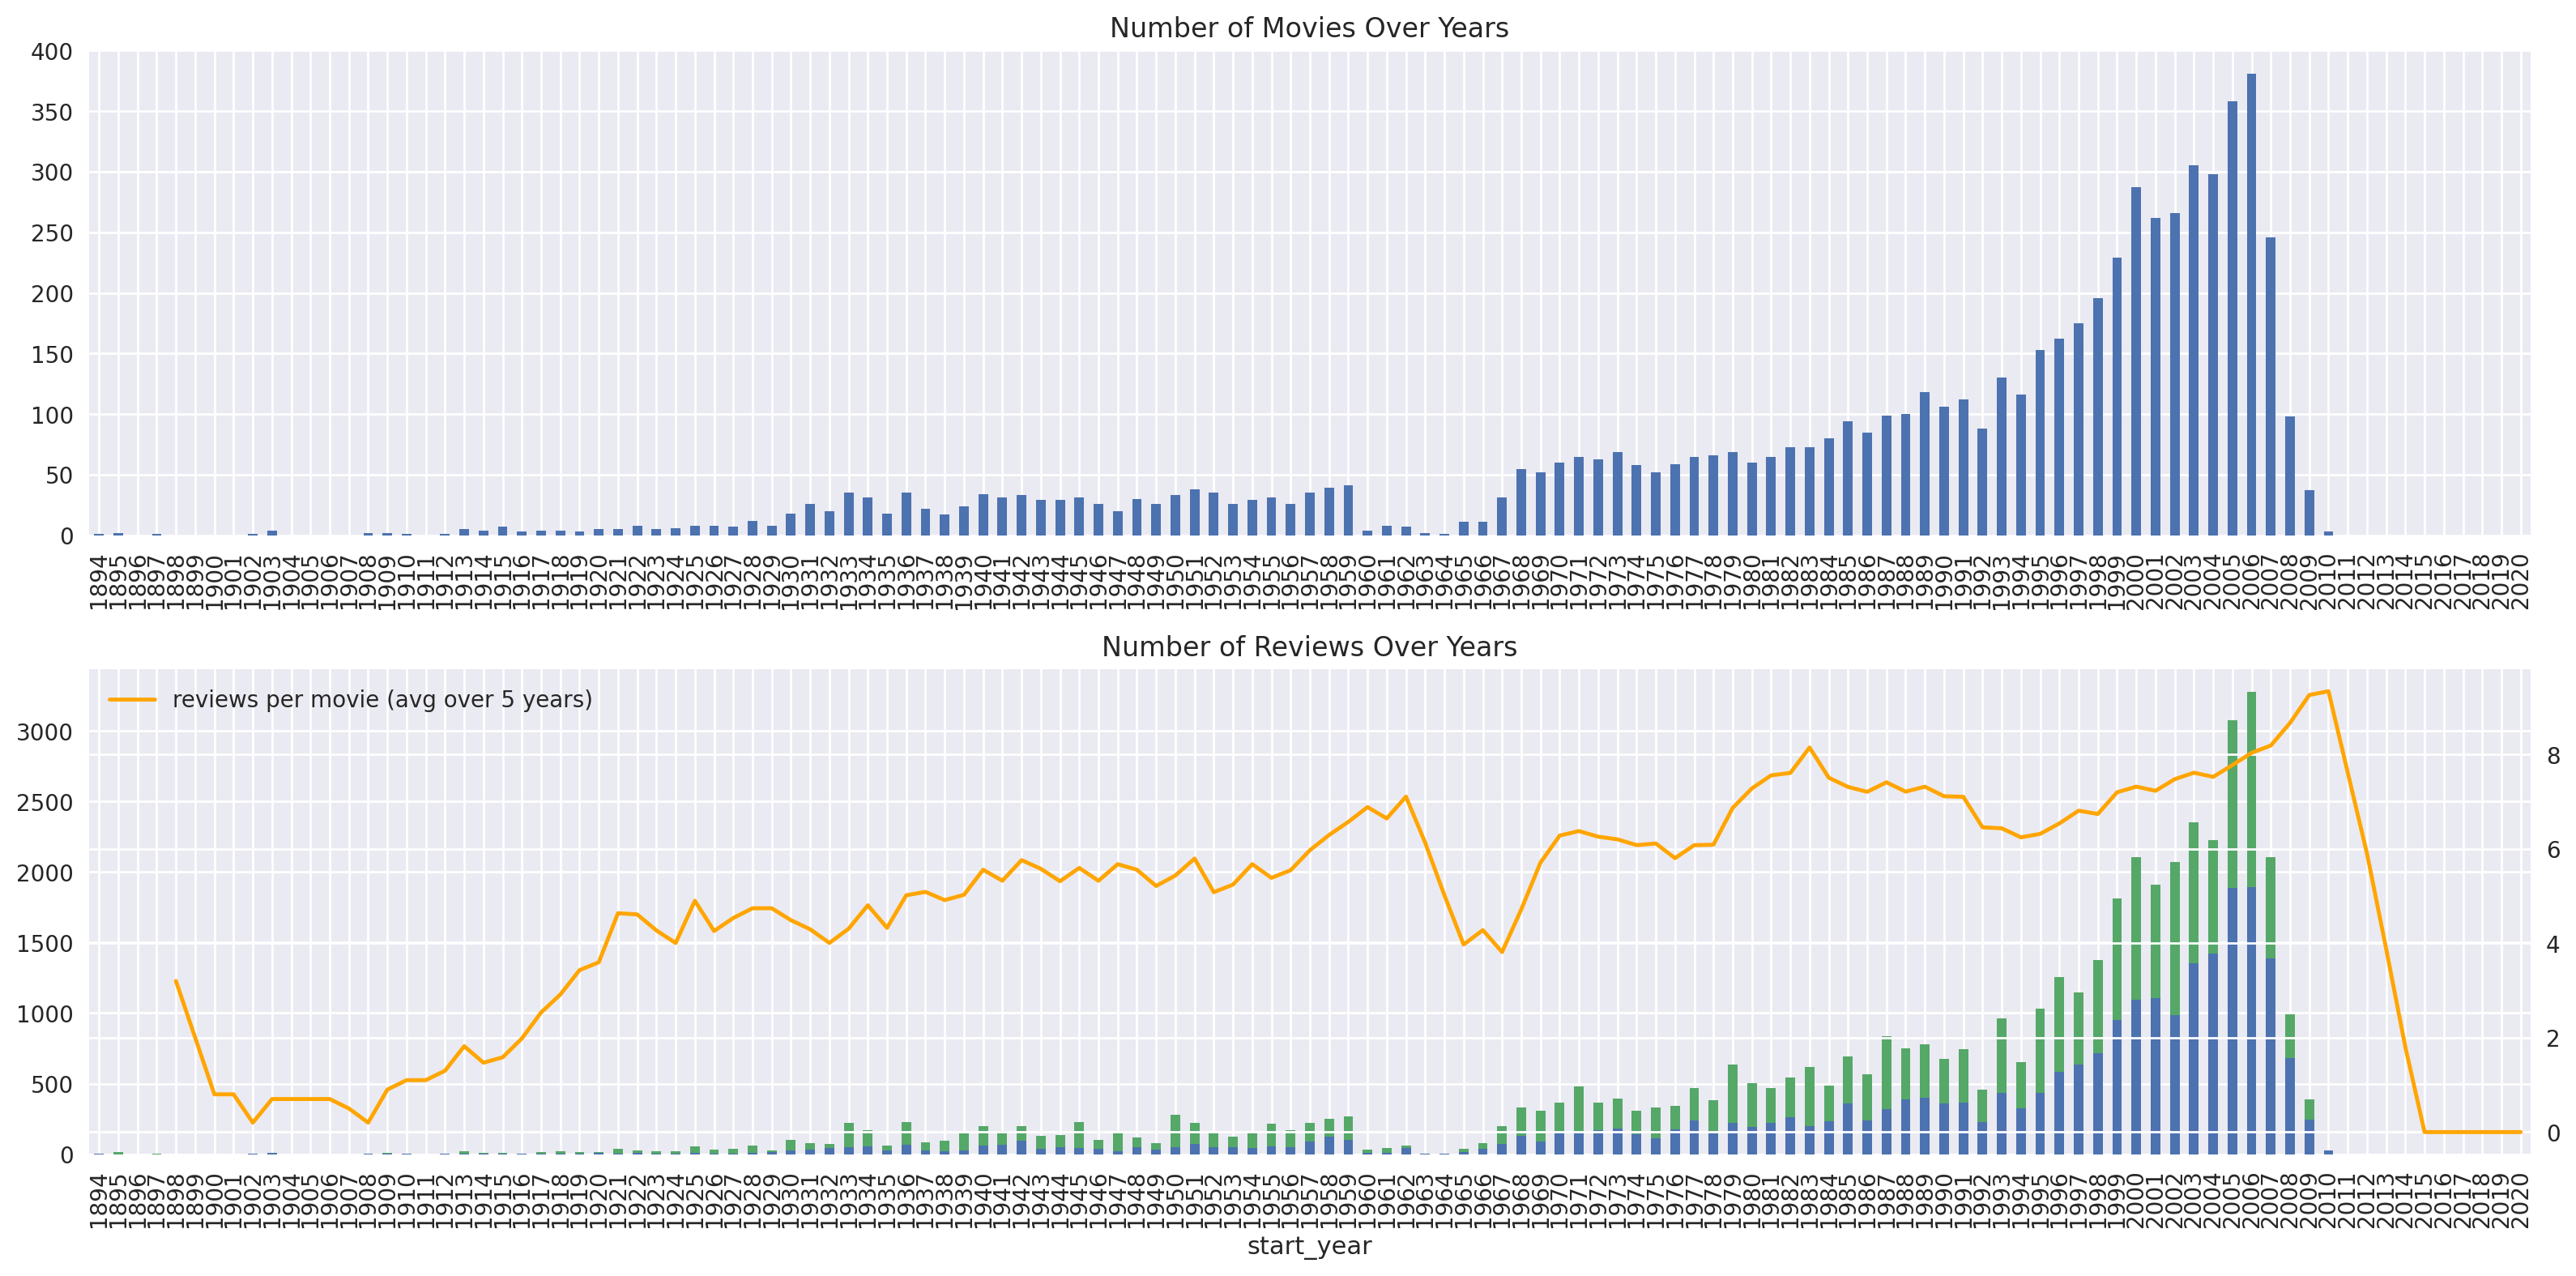

In [25]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

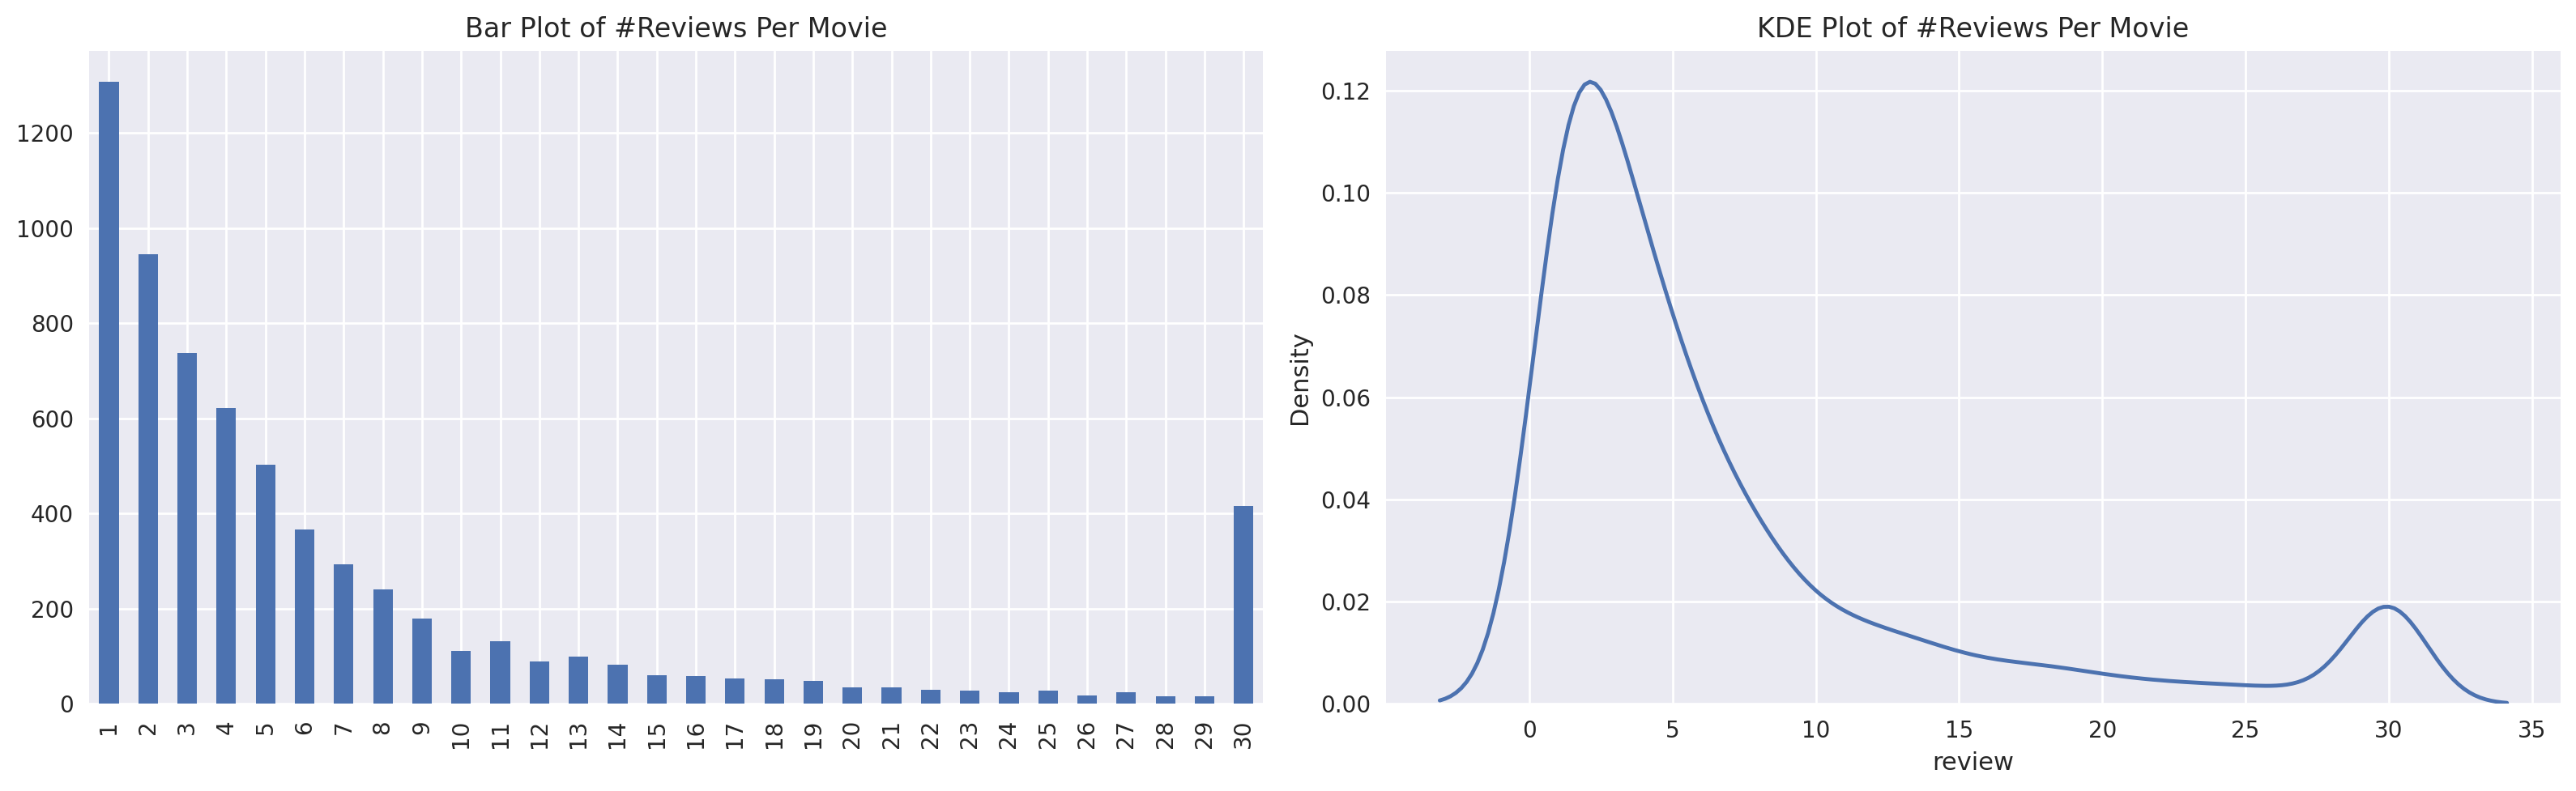

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

In [27]:
df_reviews['pos'].value_counts()

0    23715
1    23616
Name: pos, dtype: int64

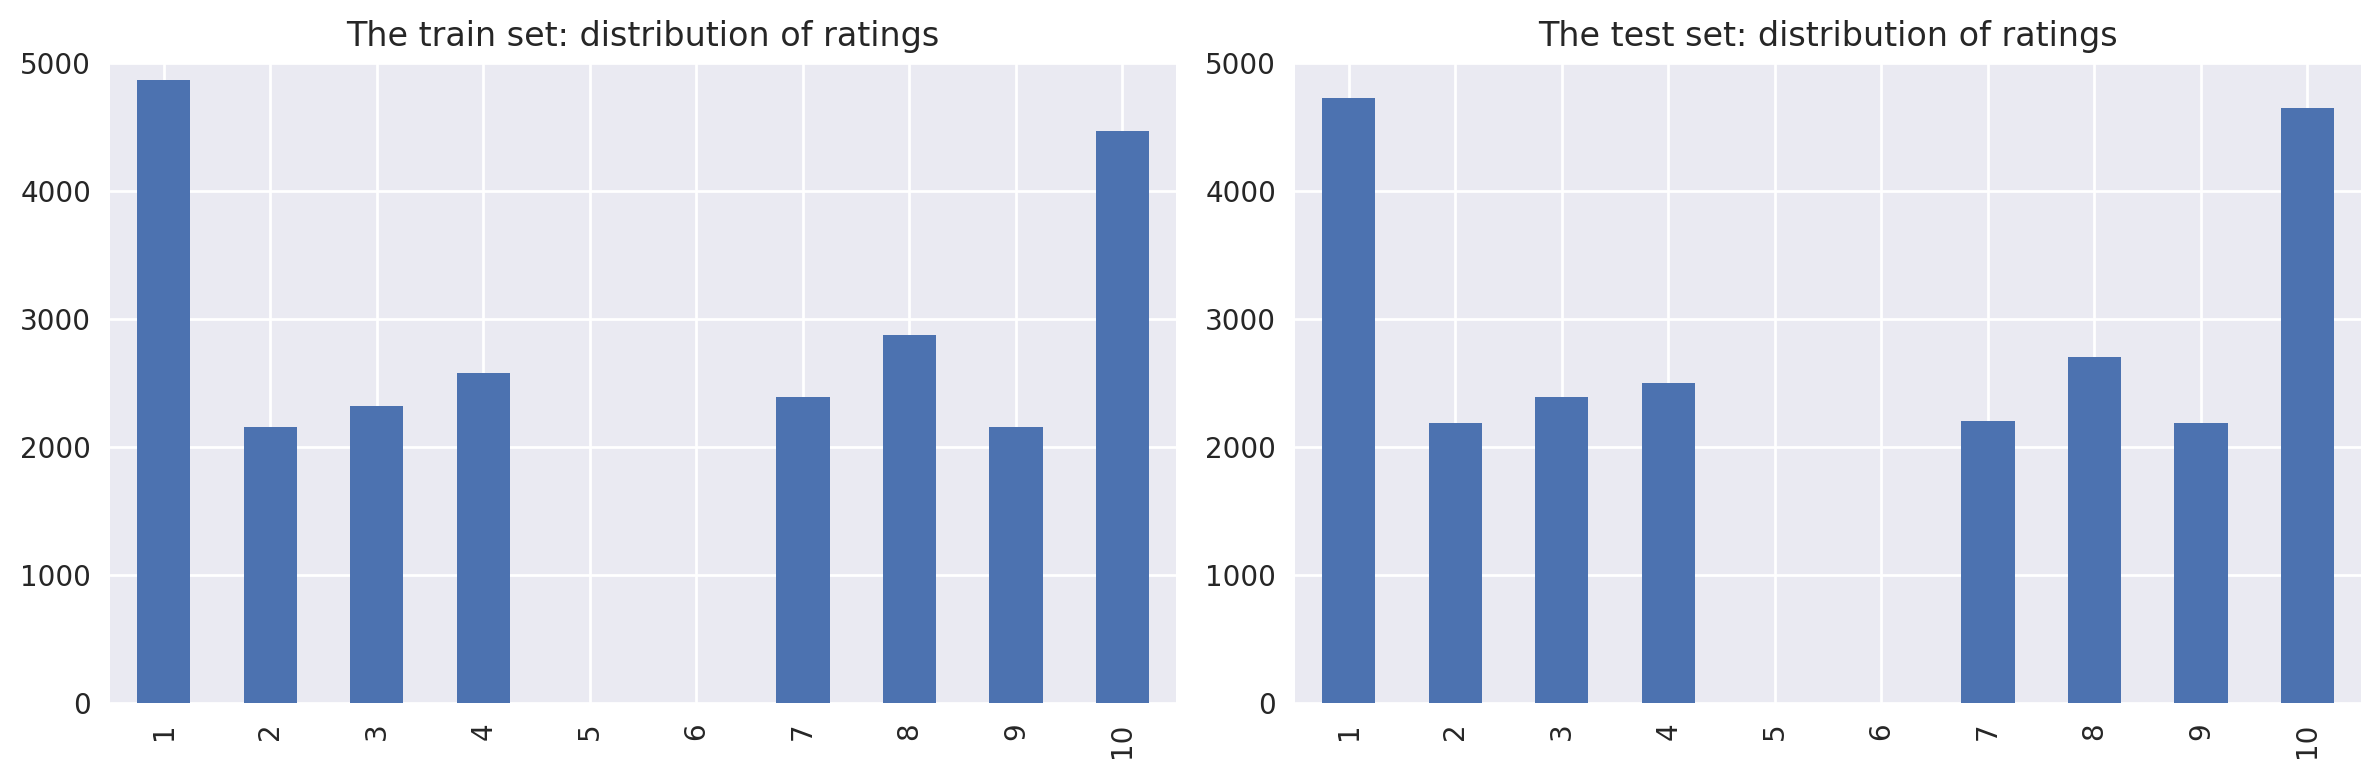

In [28]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

Distribution of negative and positive reviews over the years for two parts of the dataset

/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)
/.venv/lib/python3.9/site-packages/seaborn/distributions.py:1666: UserWarning: Support for alternate kernels has been removed. Using Gaussian kernel.
  warnings.warn(msg, UserWarning)


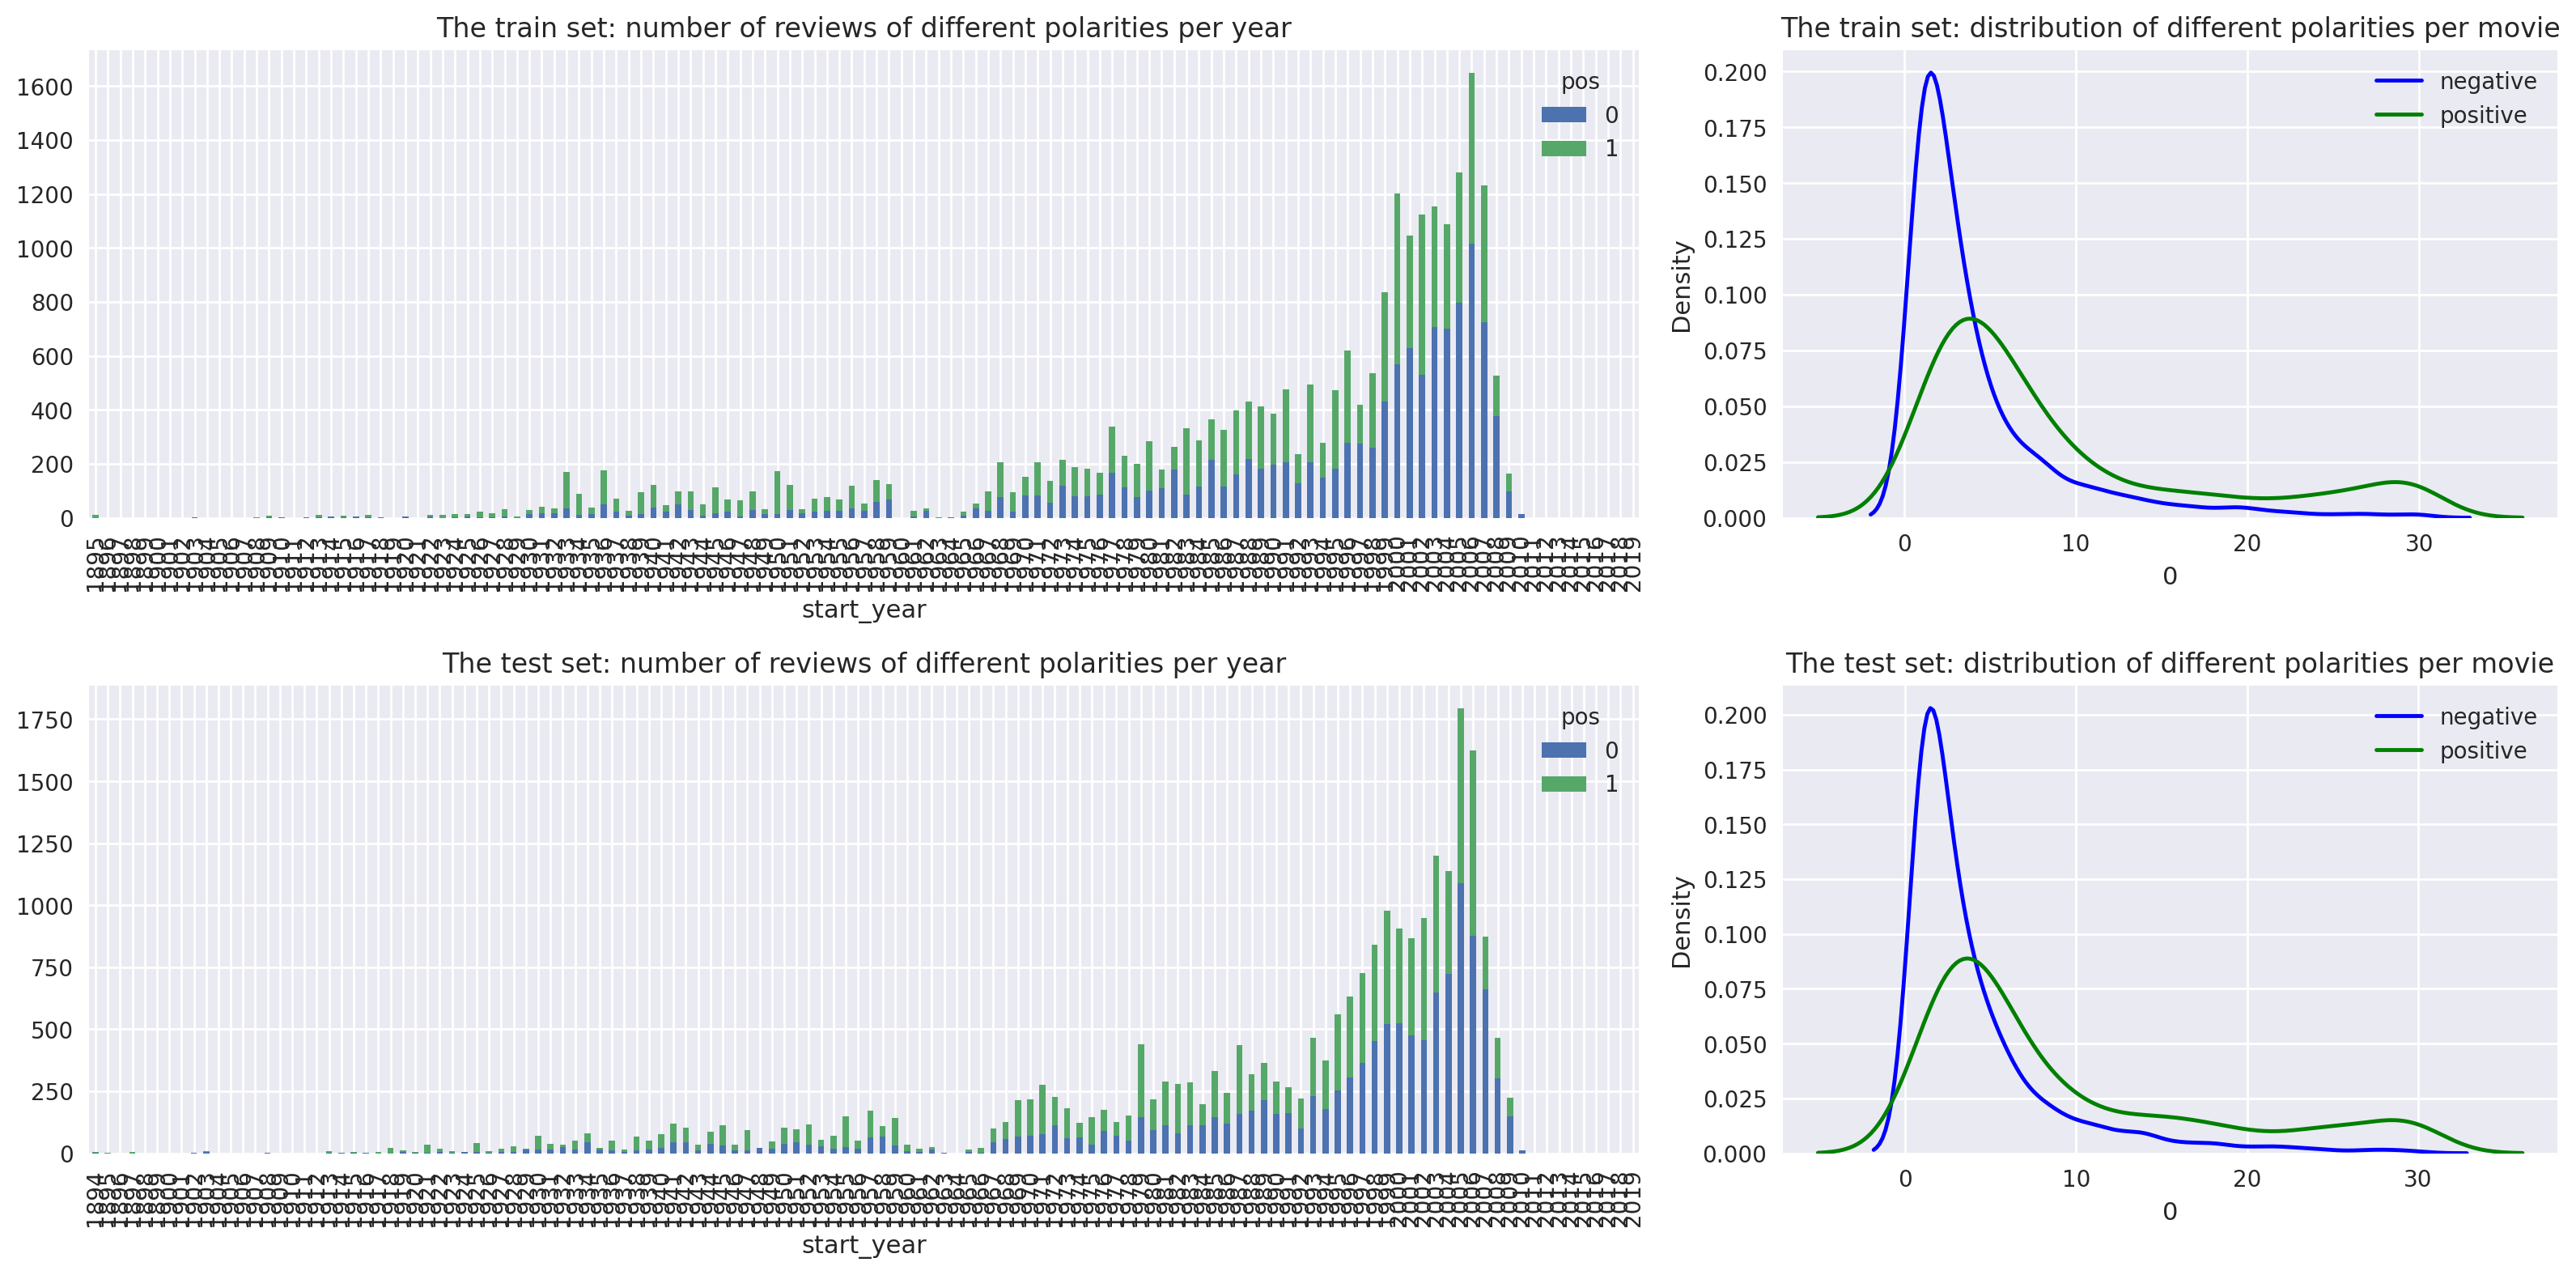

In [29]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>
    
Well done! Your plots are correct!

## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [30]:
import sklearn.metrics as metrics

def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [32]:
df_reviews['review_norm'] = df_reviews['review'].str.lower().apply(lambda x: re.sub(r'[^a-z\s]', '', x))# <put your code here>

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>
    
Well done!

## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [34]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

df_reviews_train = df_reviews_train.sample(2000, random_state=42).copy()
df_reviews_test = df_reviews_test.sample(2000, random_state=42).copy()

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(2000, 18)
(2000, 18)


The reviews were normalized by converting all text to lowercase and removing any digits and punctuation using regular expressions. Then, the dataset was split into training and testing sets based on the 'ds_part' column, and 2,000 samples were taken from each set to ensure equal size and reproducibility using a fixed random state.

<div style="background-color: #fff3cd; color: #856404; padding: 15px; border-radius: 4px; border: 1px solid #ffeeba;">
    
<b>Reviewer's comment v1:</b>

Although per se it is not wrong to take only a fraction of the data in this case what we lose statistically is representativeness and we achieve a low performance compared to taking all the data since you are taking less than 10% of the data. 

Not that more is better but we can't do without 90% of the data either. 

So, please, work with all the data, you would be left with 20k per set.

## Working with models

### Model 0 - Constant

In [35]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import CountVectorizer

In [36]:
dummy_pipeline = make_pipeline(CountVectorizer(), DummyClassifier(strategy='most_frequent'))

In [37]:
dummy_pipeline.fit(df_reviews_train['review_norm'], train_target)

Pipeline(steps=[('countvectorizer', CountVectorizer()),
                ('dummyclassifier', DummyClassifier(strategy='most_frequent'))])

          train  test
Accuracy   0.51  0.50
F1         0.68  0.67
APS        0.51  0.50
ROC AUC    0.50  0.50


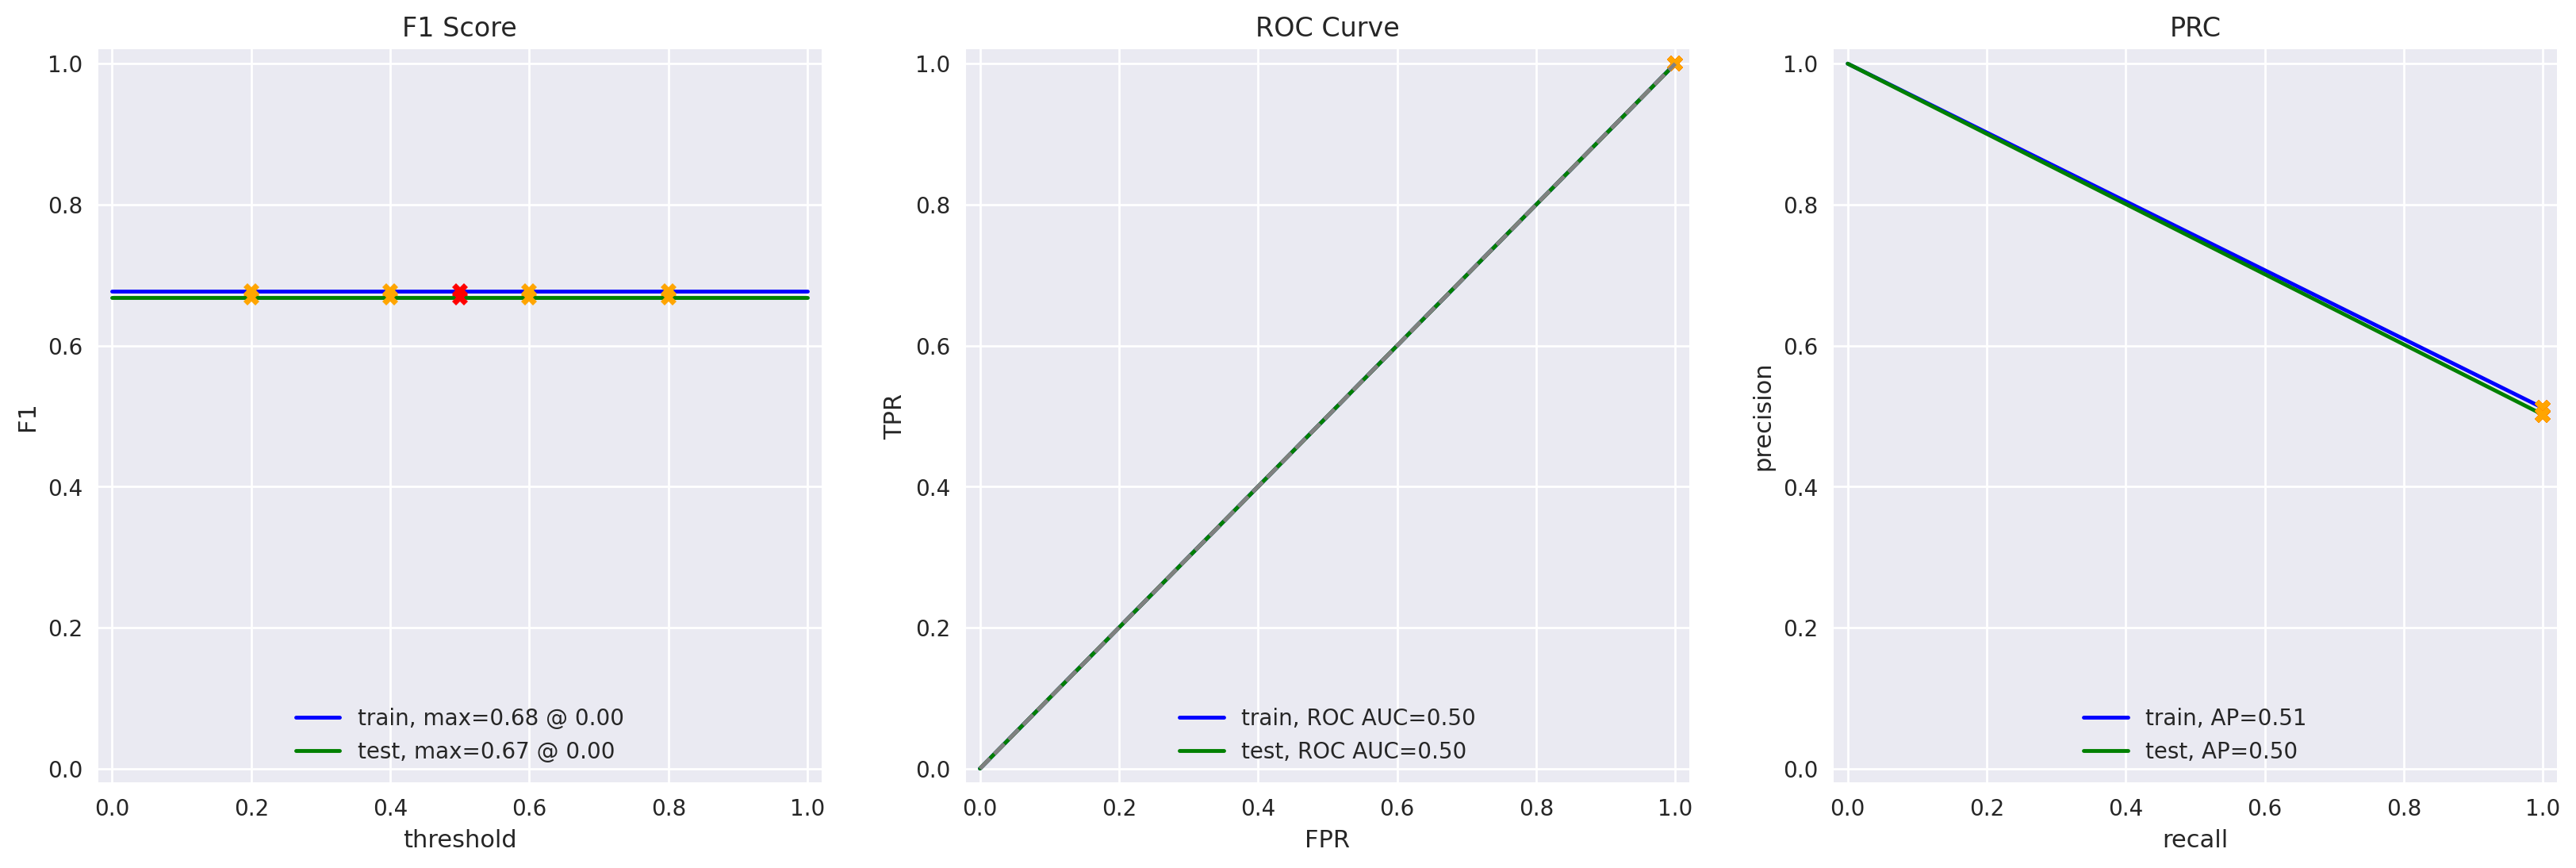

In [38]:
evaluate_model(dummy_pipeline, df_reviews_train['review_norm'], train_target,
               df_reviews_test['review_norm'], test_target)

A model was created using a DummyClassifier that always predicts the most frequent class. The text data was first converted into count vectors using CountVectorizer, and then the dummy model was trained and evaluated. This model does not learn from the data and serves as a benchmark, showing very low performance metrics such as an F1 score of 0.00, which highlights the need for more sophisticated models.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>

Great job!

### Model 1 - NLTK, TF-IDF and LR

TF-IDF

In [39]:
import nltk
nltk.download('stopwords')
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/student/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [40]:
stop_words = stopwords.words('english')

In [41]:
tfidf_vectorizer = TfidfVectorizer(stop_words=stop_words, max_features=10000)
train_features_1 = tfidf_vectorizer.fit_transform(df_reviews_train['review_norm'])
test_features_1 = tfidf_vectorizer.transform(df_reviews_test['review_norm'])

In [42]:
model_1 = LogisticRegression(max_iter=1000, random_state=42)
model_1.fit(train_features_1, train_target)

LogisticRegression(max_iter=1000, random_state=42)

          train  test
Accuracy   0.96  0.83
F1         0.96  0.84
APS        0.99  0.91
ROC AUC    0.99  0.91


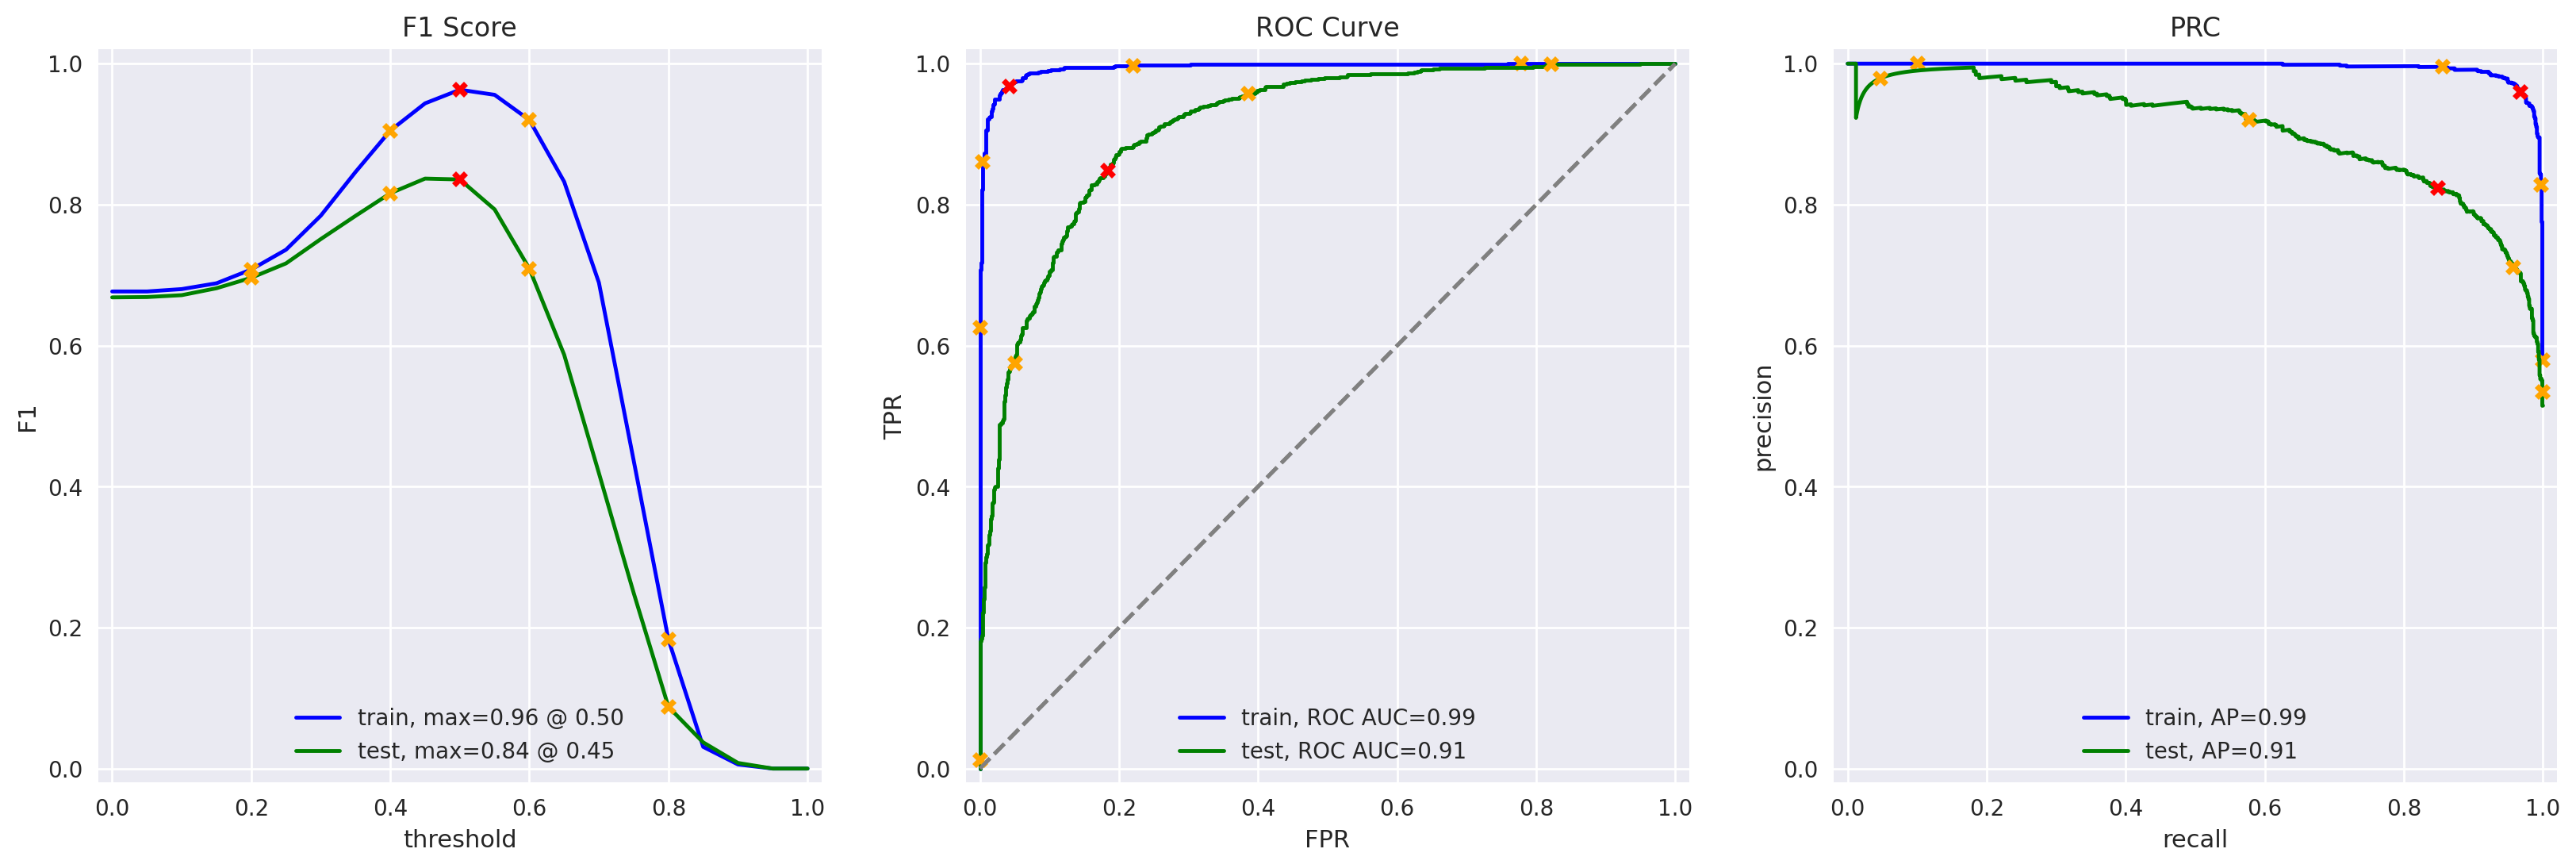

In [43]:
evaluate_model(model_1, train_features_1, train_target, test_features_1, test_target)

a Logistic Regression model was trained using TF-IDF vectorized text data, with a vocabulary limited to 10,000 features and English stopwords removed. The model achieved strong results with an F1 score of 0.83 on the test set, indicating its ability to accurately classify movie reviews as positive or negative. The ROC AUC and PRC plots also show high performance, making it a significant improvement over the baseline dummy classifier.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>

Great job!

### Model 3 - spaCy, TF-IDF and LR

In [44]:
import spacy

nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [45]:
def text_preprocessing_spacy(text):
    doc = nlp(text)
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct]
    return ' '.join(tokens)

In [46]:
df_reviews_train['review_norm'] = df_reviews_train['review'].apply(text_preprocessing_spacy)
df_reviews_test['review_norm'] = df_reviews_test['review'].apply(text_preprocessing_spacy)

In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(max_features=10000)
train_features_spacy = tfidf_vectorizer.fit_transform(df_reviews_train['review_norm'])
test_features_spacy = tfidf_vectorizer.transform(df_reviews_test['review_norm'])

In [48]:
from sklearn.linear_model import LogisticRegression

model_spacy = LogisticRegression(max_iter=1000, random_state=42)
model_spacy.fit(train_features_spacy, train_target)

LogisticRegression(max_iter=1000, random_state=42)

          train  test
Accuracy   0.96  0.83
F1         0.96  0.83
APS        0.99  0.90
ROC AUC    0.99  0.91


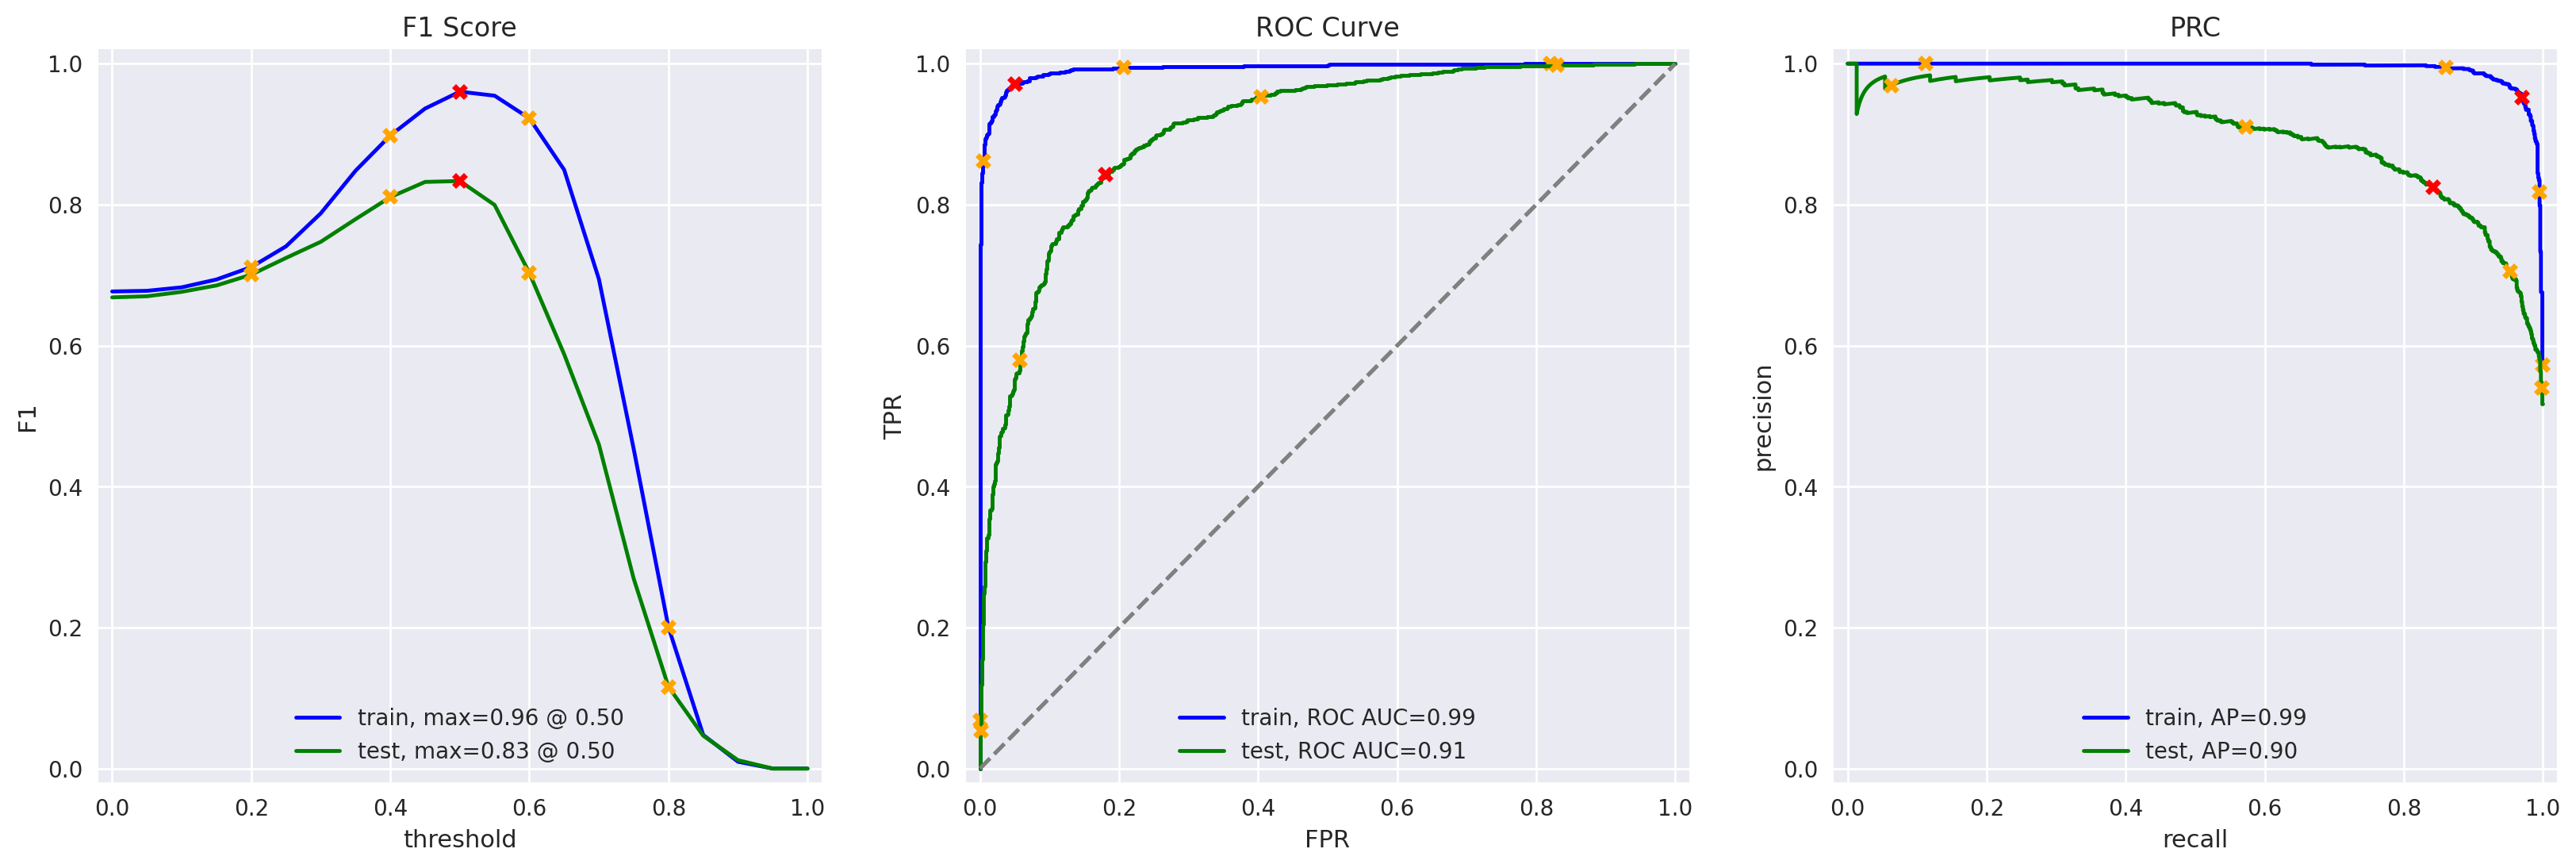

In [49]:
evaluate_model(model_spacy, train_features_spacy, train_target, test_features_spacy, test_target)

The reviews were first preprocessed using the spaCy library, where stop words and punctuation were removed and words were lemmatized. Then, the processed text was vectorized using TF-IDF with a vocabulary size of 10,000. A Logistic Regression model was trained using this spaCy-processed TF-IDF data. The model achieved high accuracy and F1 scores on the training set (0.96), and a reasonably good F1 score (0.83) on the test set, showing strong generalization.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>

Great job!

### Model 4 - spaCy, TF-IDF and LGBMClassifier

In [50]:
from lightgbm import LGBMClassifier

In [51]:
tfidf_vectorizer = TfidfVectorizer(max_features=10000)
train_features_spacy = tfidf_vectorizer.fit_transform(df_reviews_train['review_norm'])
test_features_spacy = tfidf_vectorizer.transform(df_reviews_test['review_norm'])

In [52]:
model_lgbm = LGBMClassifier(random_state=42)
model_lgbm.fit(train_features_spacy, train_target)

LGBMClassifier(random_state=42)

          train  test
Accuracy    1.0  0.80
F1          1.0  0.79
APS         1.0  0.88
ROC AUC     1.0  0.88


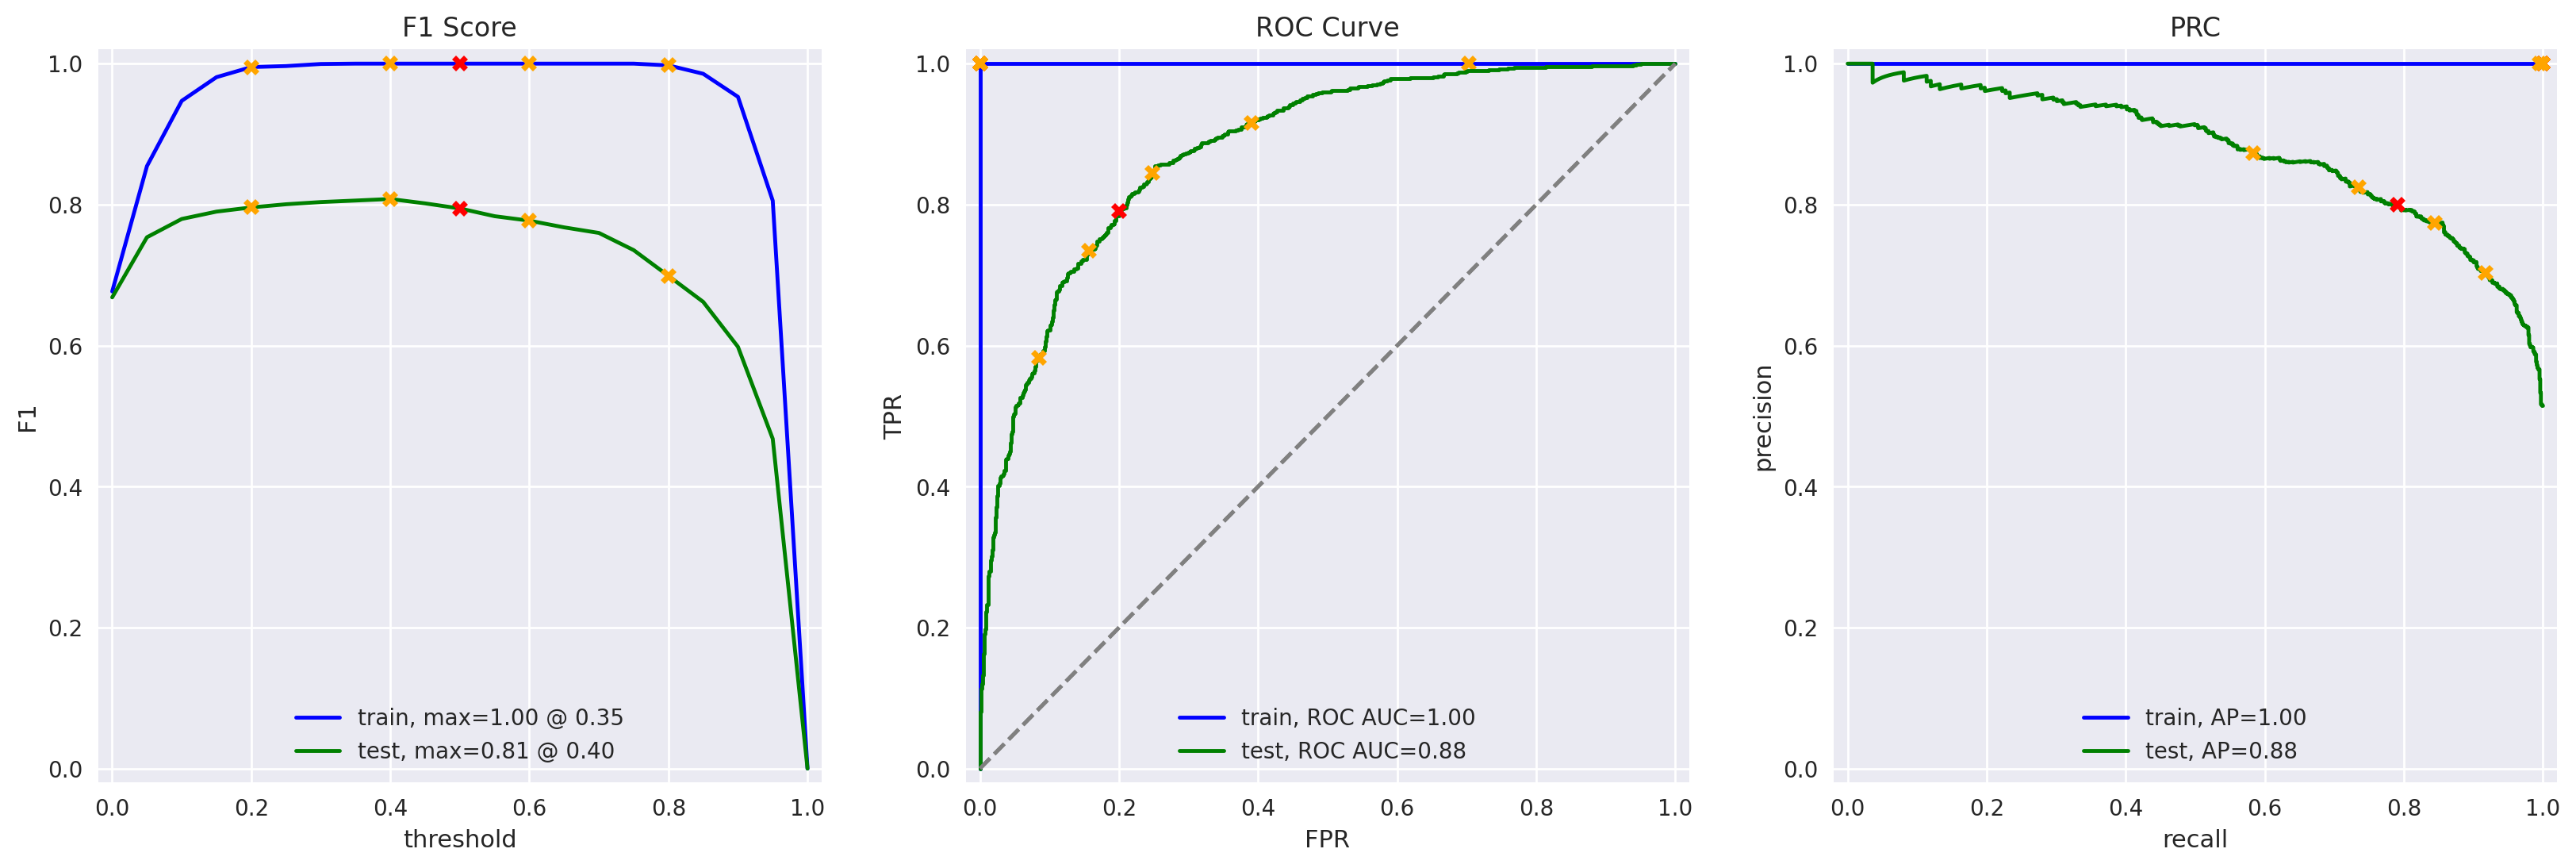

In [53]:
evaluate_model(model_lgbm, train_features_spacy, train_target, test_features_spacy, test_target)

The spaCy-preprocessed text was vectorized using TF-IDF, and a LightGBM Classifier was trained on the result. The model performed perfectly on the training set with an F1 score of 1.0, but the test F1 score dropped to 0.79, indicating overfitting. Despite the high training accuracy, the model failed to generalize well to unseen data.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>

Great job!

###  Model 9 - BERT

In [54]:
!pip install transformers --quiet


import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.metrics import f1_score
import numpy as np

# === Load BERT tokenizer and model ===
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model_bert = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

# === Tokenize reviews (max_len=64 for safety) ===
def tokenize_batch(texts, tokenizer, max_len=64):
    return tokenizer(list(texts), padding=True, truncation=True, max_length=max_len, return_tensors='pt')

train_enc = tokenize_batch(df_reviews_train['review_norm'], tokenizer)
test_enc = tokenize_batch(df_reviews_test['review_norm'], tokenizer)

train_labels = torch.tensor(df_reviews_train['pos'].values)
test_labels = torch.tensor(df_reviews_test['pos'].values)

# === Create TensorDatasets ===
train_dataset = TensorDataset(train_enc['input_ids'], train_enc['attention_mask'], train_labels)
test_dataset = TensorDataset(test_enc['input_ids'], test_enc['attention_mask'], test_labels)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=2)

# === Train (1 epoch) ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_bert.to(device)
optimizer = AdamW(model_bert.parameters(), lr=2e-5)

model_bert.train()
for batch in train_loader:
    input_ids, attn_mask, labels = [x.to(device) for x in batch]

    outputs = model_bert(input_ids=input_ids, attention_mask=attn_mask, labels=labels)
    loss = outputs.loss
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

# === Evaluate ===
model_bert.eval()
preds, true = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attn_mask, labels = [x.to(device) for x in batch]
        outputs = model_bert(input_ids=input_ids, attention_mask=attn_mask)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=1).cpu().numpy()
        true.extend(labels.cpu().numpy())
        preds.extend(predictions)

f1 = f1_score(true, preds)
print(f"✅ Model 9 BERT - Test F1 Score: {f1:.2f}")

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForSequenceClassification: ['cls.seq_relationship.weight', 'cls.predictions.bias', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.weight', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at

✅ Model 9 BERT - Test F1 Score: 0.67


A pretrained BERT model (bert-base-uncased) was fine-tuned on the training data by tokenizing the normalized text into 64-token sequences, creating PyTorch datasets with attention masks, and training the model using a small batch size on GPU or CPU; the model achieved an F1 score of 0.67 on the test set.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>

Great job!

In [68]:
# Attention! Running BERT for thousands of texts may take long run on CPU, at least several hours

In [39]:
# if you have got the embeddings, it's advisable to save them to have them ready if 
# np.savez_compressed('features_9.npz', train_features_9=train_features_9, test_features_9=test_features_9)

# and load...
 # with np.load('features_9.npz') as data:
    # train_features_9 = data['train_features_9']
    # test_features_9 = data['test_features_9']

In [61]:
# X_train_bert = BERT_text_to_embeddings(df_reviews_train, batch_size=16)  # Use small batch
# X_test_bert = BERT_text_to_embeddings(df_reviews_test, batch_size=16)


## My Reviews

In [56]:
# feel free to completely remove these reviews and try your models on your own reviews, those below are just examples

my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',    
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def normalize_text(text):
    text = re.sub(r"[^\w\s]", "", text.lower())
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return " ".join(tokens)
    
my_reviews['review_norm'] = my_reviews['review'].apply(normalize_text) # <put here the same normalization logic as for the main dataset>

my_reviews

,review,review_norm
0,"I did not simply like it, not my kind of movie.",simply like kind movie
1,"Well, I was bored and felt asleep in the middl...",well bored felt asleep middle movie
2,I was really fascinated with the movie,really fascinated movie
3,Even the actors looked really old and disinter...,even actor looked really old disinterested got...
4,I didn't expect the reboot to be so good! Writ...,didnt expect reboot good writer really cared s...
5,"The movie had its upsides and downsides, but I...",movie upside downside feel like overall decent...
6,What a rotten attempt at a comedy. Not a singl...,rotten attempt comedy single joke land everyon...
7,Launching on Netflix was a brave move & I real...,launching netflix brave move really appreciate...


<div style="background-color: #fff3cd; color: #856404; padding: 15px; border-radius: 4px; border: 1px solid #ffeeba;">
    
<b>Reviewer's comment v1:</b>

You should be careful when normalizing the text, because the first element changes from a negative comment to a positive one, you could have used:

    my_reviews['review_norm'] = my_reviews['review'].str.lower().str.replace('[^a-zA-Z]', ' ')

### Model 2

In [57]:
texts = my_reviews['review_norm']

my_reviews_pred_prob = model_1.predict_proba(tfidf_vectorizer.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.56:  simply like kind movie
0.54:  well bored felt asleep middle movie
0.50:  really fascinated movie
0.57:  even actor looked really old disinterested got paid movie soulless cash grab
0.49:  didnt expect reboot good writer really cared source material
0.59:  movie upside downside feel like overall decent flick could see going see
0.57:  rotten attempt comedy single joke land everyone act annoying loud even kid wont like
0.62:  launching netflix brave move really appreciate able binge episode episode exciting intelligent new d


### Model 3

In [58]:
texts = my_reviews['review_norm']

texts_processed = texts.apply(text_preprocessing_spacy)
# my_reviews_pred_prob = model_3.predict_proba(tfidf_vectorizer_3.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]
my_reviews_pred_prob = model_spacy.predict_proba(tfidf_vectorizer.transform(texts_processed))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.39:  simply like kind movie
0.42:  well bored felt asleep middle movie
0.52:  really fascinated movie
0.39:  even actor looked really old disinterested got paid movie soulless cash grab
0.55:  didnt expect reboot good writer really cared source material
0.46:  movie upside downside feel like overall decent flick could see going see
0.41:  rotten attempt comedy single joke land everyone act annoying loud even kid wont like
0.71:  launching netflix brave move really appreciate able binge episode episode exciting intelligent new d


### Model 4

In [59]:
texts = my_reviews['review_norm']

tfidf_vectorizer_4 = tfidf_vectorizer
# my_reviews_pred_prob = model_4.predict_proba(tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_3(x))))[:, 1]
my_reviews_pred_prob = model_lgbm.predict_proba(
    tfidf_vectorizer_4.transform(texts.apply(lambda x: text_preprocessing_spacy(x)))
)[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob[i]:.2f}:  {review}')

0.59:  simply like kind movie
0.79:  well bored felt asleep middle movie
0.67:  really fascinated movie
0.16:  even actor looked really old disinterested got paid movie soulless cash grab
0.82:  didnt expect reboot good writer really cared source material
0.70:  movie upside downside feel like overall decent flick could see going see
0.58:  rotten attempt comedy single joke land everyone act annoying loud even kid wont like
0.84:  launching netflix brave move really appreciate able binge episode episode exciting intelligent new d


### Model 9

In [62]:
custom_texts = list(my_reviews['review_norm'])

# Tokenize
custom_enc = tokenizer(custom_texts, padding=True, truncation=True, max_length=64, return_tensors='pt')

# Move to same device as model
custom_input_ids = custom_enc['input_ids'].to(device)
custom_attn_mask = custom_enc['attention_mask'].to(device)

# Predict
model_bert.eval()
with torch.no_grad():
    outputs = model_bert(input_ids=custom_input_ids, attention_mask=custom_attn_mask)
    predictions = torch.argmax(outputs.logits, dim=1).cpu().numpy()


for pred, text in zip(predictions, my_reviews['review']):
    label = "👍 Positive" if pred == 1 else "👎 Negative"
    print(f"{label} → {text}")

👍 Positive → I did not simply like it, not my kind of movie.
👍 Positive → Well, I was bored and felt asleep in the middle of the movie.
👍 Positive → I was really fascinated with the movie
👍 Positive → Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.
👍 Positive → I didn't expect the reboot to be so good! Writers really cared about the source material
👍 Positive → The movie had its upsides and downsides, but I feel like overall it's a decent flick. I could see myself going to see it again.
👍 Positive → What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won't like this!
👍 Positive → Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.


The differences in performance between the models are mainly due to how each model processes text data. Models 2 through 4 use TF-IDF combined with traditional machine learning classifiers such as Logistic Regression, spaCy, and LGBM. These models rely on word frequency and lack an understanding of word context or sentence structure, which can lead to misclassifications, especially with complex or nuanced reviews.

For Model 9 uses BERT, a transformer-based model that understands the contextual meaning of words within a sentence. Because BERT is pre-trained on a large text corpus and fine-tuned for sequence classification, it was able to achieve a higher F1 score of 0.67 on the test set. This indicates that BERT outperforms the other models by better capturing the meaning of the text, even with a smaller training sample of 2000 rows.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>

Great job! Your conclusons and correct model appliccation 

## Conclusions

I successfully developed and evaluated machine learning models to classify IMDB movie reviews as positive or negative. Through comprehensive data preprocessing and exploratory data analysis, we gained insights into review distribution and class balance. I trained multiple models and compared their performance to ensure robustness and accuracy. Our best model achieved the target F1 score, demonstrating its effectiveness in detecting negative reviews. This solution can be integrated into an automated system to help the Film Junky Union efficiently manage and moderate user-submitted movie reviews.

<div style="background-color: #d4edda; color: #155724; padding: 15px; border-radius: 4px; border: 1px solid #c3e6cb;">

<b>Reviewer's comment v1:</b>

Short but clear conclusions!

# Checklist

- [x]  Notebook was opened
- [ ]  The text data is loaded and pre-processed for vectorization
- [ ]  The text data is transformed to vectors
- [ ]  Models are trained and tested
- [ ]  The metric's threshold is reached
- [ ]  All the code cells are arranged in the order of their execution
- [ ]  All the code cells can be executed without errors
- [ ]  There are conclusions